In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airfoil-selfnoise-dataset/AirfoilSelfNoise.csv
/kaggle/input/abalone-dataset/abalone.csv


In [2]:
# Install dependencies
!pip install tabpfn autogluon catboost lightgbm xgboost pandas numpy matplotlib seaborn
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions[all]
!pip install scikit-learn==1.5.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to

In [3]:
!pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"

  Cloning https://github.com/PriorLabs/tabpfn-extensions.git to /tmp/pip-install-5irmuj9o/tabpfn-extensions_cf40d8e1ee3e4d5fb29f9178f6790df7
  Running command git clone --filter=blob:none --quiet https://github.com/PriorLabs/tabpfn-extensions.git /tmp/pip-install-5irmuj9o/tabpfn-extensions_cf40d8e1ee3e4d5fb29f9178f6790df7
  Resolved https://github.com/PriorLabs/tabpfn-extensions.git to commit 3957f2d855cae73cfe6c0949b93dfc1846701426
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached autogluon.common-1.3.2b20250729-py3-none-any.whl
  Using cached autogluon.features-1.3.2b20250729-py3-none-any.whl
  Using cached autogluon.core-1.3.2b20250729-py3-none-any.whl
  Using cached autogluon.tabular-1.3.2b20250729-py3-none-any.whl
  Created wheel for tabpfn-extensions: filename=tabpfn_extensions-0.1.1-py3-none-any.whl size=96765 sha256=540e4a094c46092cf4c4d37e70fc37c761d5f6ab0d9dff2d77de551dc2c15dc9

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_profiling import ProfileReport
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import catboost as cb
import lightgbm as lgb
import xgboost as xgb

# Optional imports with fallbacks
# AutoGluon
try:
    from autogluon.tabular import TabularPredictor
    AGLUON_AVAILABLE = True
except ImportError as e:
    print("Warning: AutoGluon import failed:", e)
    AGLUON_AVAILABLE = False

# TabPFN
# from tabpfn import TabPFNClassifier
# try:
#   from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier, AutoTabPFNRegressor
# except:
#   raise SystemError('Please restart the session to fix this import.')

from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

/tmp/ipykernel_36/1619273419.py:5: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [5]:
# 3) Load dataset (update the file path as needed)
# heart-disease-dataset = '/kaggle/input/heart-disease-dataset'
# df = pd.read_csv(heart-disease-dataset)

# ada_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/ada_dataset.csv'
# df = pd.read_csv(ada_dataset)

abalone = '/kaggle/input/abalone-dataset/abalone.csv'
df = pd.read_csv(abalone)

# blood_transfusion-service-center_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/blood_transfusion-service-center.csv'
# df = pd.read_csv(blood_transfusion-service-center_dataset)

# car_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/car.csv'
# df = pd.read_csv(car_dataset)

# chum_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/chum.csv'
# df = pd.read_csv(chum_dataset)

# cmc_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/cmc.csv'
# df = pd.read_csv(cmc_dataset)

# credit-g_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/credit-g.csv'
# df = pd.read_csv(credit-g_dataset)

In [6]:
# 4) Dataset overview and information
print("Shape of the dataset:", df.shape)
df.info()
print("\nFirst few rows:")
display(df.head())
print("\nLast few rows:")
display(df.tail())
print("\nDescriptive statistics:")
display(df.describe(include='all').T)
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nMemory usage per column:")
display(df.memory_usage(deep=True))
print("\nUnique value counts per column:")
display(df.nunique())
print("\nData types of each column:")
display(df.dtypes)

Shape of the dataset: (4177, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB

First few rows:


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7



Last few rows:


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12



Descriptive statistics:


...

Index                132
Sex               242266
Length             33416
Diameter           33416
Height             33416
Whole weight       33416
Shucked weight     33416
Viscera weight     33416
Shell weight       33416
Rings              33416
dtype: int64


Unique value counts per column:


Sex                  3
Length             134
Diameter           111
Height              51
Whole weight      2429
Shucked weight    1515
Viscera weight     880
Shell weight       926
Rings               28
dtype: int64


Data types of each column:


Sex                object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

### 5. Separate target and features

In [7]:
# Keep target vector separate from X
target = 'Rings'
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataframe.")
y = df[target]
X = df.drop(columns=target)

In [8]:
# Make copies of the raw feature matrix and target vector
raw_features = X.copy()
raw_target = y.copy()

In [9]:
raw_features.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


### Raw Data Encoding (No other preprocessing)

In [10]:
from sklearn.preprocessing import LabelEncoder

encoded_raw_features = raw_features.copy()

# Apply Label Encoding to categorical columns only
for col in encoded_raw_features.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    encoded_raw_features[col] = le.fit_transform(encoded_raw_features[col])

print("Raw features encoded (categoricals only).")

Raw features encoded (categoricals only).


In [11]:
encoded_raw_features.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [12]:
from sklearn.model_selection import train_test_split

# --- Split raw encoded features ---
raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(
    encoded_raw_features, raw_target, test_size=0.2, random_state=42
)

### Data Pre-processing

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Make copies to avoid altering raw data
processed_X = X.copy()
processed_y = y.copy()

# --- Step 1: Encode categorical features in X ---
cat_cols = processed_X.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    le = LabelEncoder()
    processed_X[col] = le.fit_transform(processed_X[col].astype(str))  # Ensure all strings

# --- Step 2: Fill missing values ---
# Numeric: mean | Categorical: most frequent
num_cols = processed_X.select_dtypes(include=["number"]).columns
cat_cols = processed_X.select_dtypes(exclude=["number"]).columns

if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='mean')
    processed_X[num_cols] = imputer_num.fit_transform(processed_X[num_cols])

if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    processed_X[cat_cols] = imputer_cat.fit_transform(processed_X[cat_cols])

# --- Step 3: Z-normalization (Standard Scaling) ---
scaler = StandardScaler()
processed_X = pd.DataFrame(scaler.fit_transform(processed_X), columns=processed_X.columns)

# --- Step 4: Encode y if needed ---
if processed_y.dtype == "object" or str(processed_y.dtype).startswith("category"):
    y_encoder = LabelEncoder()
    processed_y = y_encoder.fit_transform(processed_y.astype(str))

print("Processed dataset ready: encoded, imputed, and normalized.")

Processed dataset ready: encoded, imputed, and normalized.


In [14]:
processed_X.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,1.151980,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217
1,1.151980,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987
2,-1.280690,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139
3,1.151980,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294
4,-0.064355,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757


In [15]:
processed_y.head()

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

In [16]:
# --- Split fully processed features ---
processed_X_train, processed_X_test, processed_y_train, processed_y_test = train_test_split(
    processed_X, processed_y, test_size=0.2, random_state=42
)

## Defining Models

In [17]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import mean_squared_error, r2_score
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Train on raw data ---
regressor_raw = TabPFNRegressor(device=device)
regressor_raw.fit(raw_X_train.values, raw_y_train.values)
raw_preds = regressor_raw.predict(raw_X_test.values)

print("TabPFN (Raw) MSE:", mean_squared_error(raw_y_test, raw_preds))
print("TabPFN (Raw) R^2 Score:", r2_score(raw_y_test, raw_preds))

# --- Train on processed data ---
regressor_proc = TabPFNRegressor(device=device)
regressor_proc.fit(processed_X_train.values, processed_y_train.values)
proc_preds = regressor_proc.predict(processed_X_test.values)

print("TabPFN (Processed) MSE:", mean_squared_error(processed_y_test, proc_preds))
print("TabPFN (Processed) R^2 Score:", r2_score(processed_y_test, proc_preds))

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN (Raw) MSE: 4.359399942170938
TabPFN (Raw) R^2 Score: 0.597291886806488
TabPFN (Processed) MSE: 4.370502597655394
TabPFN (Processed) R^2 Score: 0.5962662696838379


In [19]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from tabpfn import TabPFNRegressor
from autogluon.tabular import TabularPredictor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import pandas as pd
import tempfile
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "MLP": MLPRegressor(random_state=42, max_iter=1000)
}

results = []

# --- Raw and Processed datasets ---
datasets = [
    ("Raw", raw_X_train, raw_X_test, raw_y_train, raw_y_test),
    ("Processed", processed_X_train, processed_X_test, processed_y_train, processed_y_test)
]

# --- Classic models ---
for name, model in models.items():
    for label, X_train, X_test, y_train, y_test in datasets:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results.append({
            "Model": f"{name}-{label}",
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": mean_squared_error(y_test, preds, squared=False),
            "R2": r2_score(y_test, preds)
        })

# --- TabPFN ---
for label, X_train, X_test, y_train, y_test in datasets:
    model = TabPFNRegressor(device=device)
    model.fit(X_train.values, y_train.values)
    preds = model.predict(X_test.values)
    results.append({
        "Model": f"TabPFN-{label}",
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds, squared=False),
        "R2": r2_score(y_test, preds)
    })

# --- AutoTabPFN ---
for label, X_train, X_test, y_train, y_test in datasets:
    model = AutoTabPFNRegressor(device=device)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": f"AutoTabPFN-{label}",
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds, squared=False),
        "R2": r2_score(y_test, preds)
    })

# --- AutoGluon ---
for label, X_train, X_test, y_train, y_test in datasets:
    train_df = X_train.copy()
    train_df["target"] = y_train
    test_df = X_test.copy()
    test_df["target"] = y_test

    with tempfile.TemporaryDirectory() as save_path:
        predictor = TabularPredictor(label="target", problem_type="regression", path=save_path)
        predictor.fit(train_df, verbosity=0)
        preds = predictor.predict(test_df.drop(columns="target"))
        results.append({
            "Model": f"AutoGluon-{label}",
            "MAE": mean_absolute_error(test_df["target"], preds),
            "RMSE": mean_squared_error(test_df["target"], preds, squared=False),
            "R2": r2_score(test_df["target"], preds)
        })
metrics_df = pd.DataFrame(results)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001656 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1294
[LightGBM] [Info] Number of data points in the train set: 3341, number of used features: 8
[LightGBM] [Info] Start training from score 9.944627
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 3341, number of used features: 8
[LightGBM] [Info] Start training from score 9.944627


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

tabpfn-v2-regressor-09gpqh39.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

	-2.0971	 = Validation score   (-root_mean_squared_error)
	12.25s	 = Training   runtime
	9.71s	 = Validation runtime
Fitting model: TabPFNv2_7_BAG_L1 ... Training model for up to 263.80s of the 263.79s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=2, gpus=1)
	-2.0994	 = Validation score   (-root_mean_squared_error)
	14.53s	 = Training   runtime
	12.16s	 = Validation runtime
Fitting model: TabPFNv2_8_BAG_L1 ... Training model for up to 249.12s of the 249.12s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=2, gpus=1)
	-2.0793	 = Validation score   (-root_mean_squared_error)
	8.84s	 = Training   runtime
	5.67s	 = Validation runtime
Fitting model: TabPFNv2_9_BAG_L1 ... Training model for up to 240.19s of the 240.19s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cp

tabpfn-v2-regressor-5wof9ojf.ckpt:   0%|          | 0.00/24.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

	-2.0796	 = Validation score   (-root_mean_squared_error)
	22.63s	 = Training   runtime
	18.59s	 = Validation runtime
Fitting model: TabPFNv2_3_BAG_L1 ... Training model for up to 325.76s of the 325.76s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=2, gpus=1)
		Generator(PCG64) at 0x799B726320A0 cannot be used to seed a numpy.random.RandomState instance
Detailed Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2169, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2055, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, total_resources=total_resources, **model_fit_kwargs)
            ^^^^^

Regression Performance Metrics:
Columns in metrics_df: ['Model', 'MAE', 'RMSE', 'R2']


,Model,MAE,RMSE,R2
0,LinearRegression-Raw,1.630561,2.250008,0.532338
1,LinearRegression-Processed,1.630561,2.250008,0.532338
2,RandomForest-Raw,1.589928,2.256425,0.529667
3,RandomForest-Processed,1.591675,2.257011,0.529423
4,GradientBoosting-Raw,1.574048,2.244432,0.534653
5,GradientBoosting-Processed,1.575621,2.245229,0.534323
6,XGBoost-Raw,1.621149,2.340607,0.493918
7,XGBoost-Processed,1.621149,2.340607,0.493918
8,LightGBM-Raw,1.554037,2.245208,0.534331
9,LightGBM-Processed,1.568564,2.262064,0.527313


Normalized Performance Metrics:


,Model,MAE,RMSE,R2
0,LinearRegression-Raw,1.051366,1.016675,0.879652
1,LinearRegression-Processed,1.051366,1.016675,0.879652
2,RandomForest-Raw,1.025167,1.019574,0.875238
3,RandomForest-Processed,1.026293,1.019839,0.874835
4,GradientBoosting-Raw,1.014927,1.014155,0.883478
5,GradientBoosting-Processed,1.015941,1.014515,0.882932
6,XGBoost-Raw,1.045298,1.057613,0.816166
7,XGBoost-Processed,1.045298,1.057613,0.816166
8,LightGBM-Raw,1.002024,1.014506,0.882946
9,LightGBM-Processed,1.011391,1.022122,0.871349


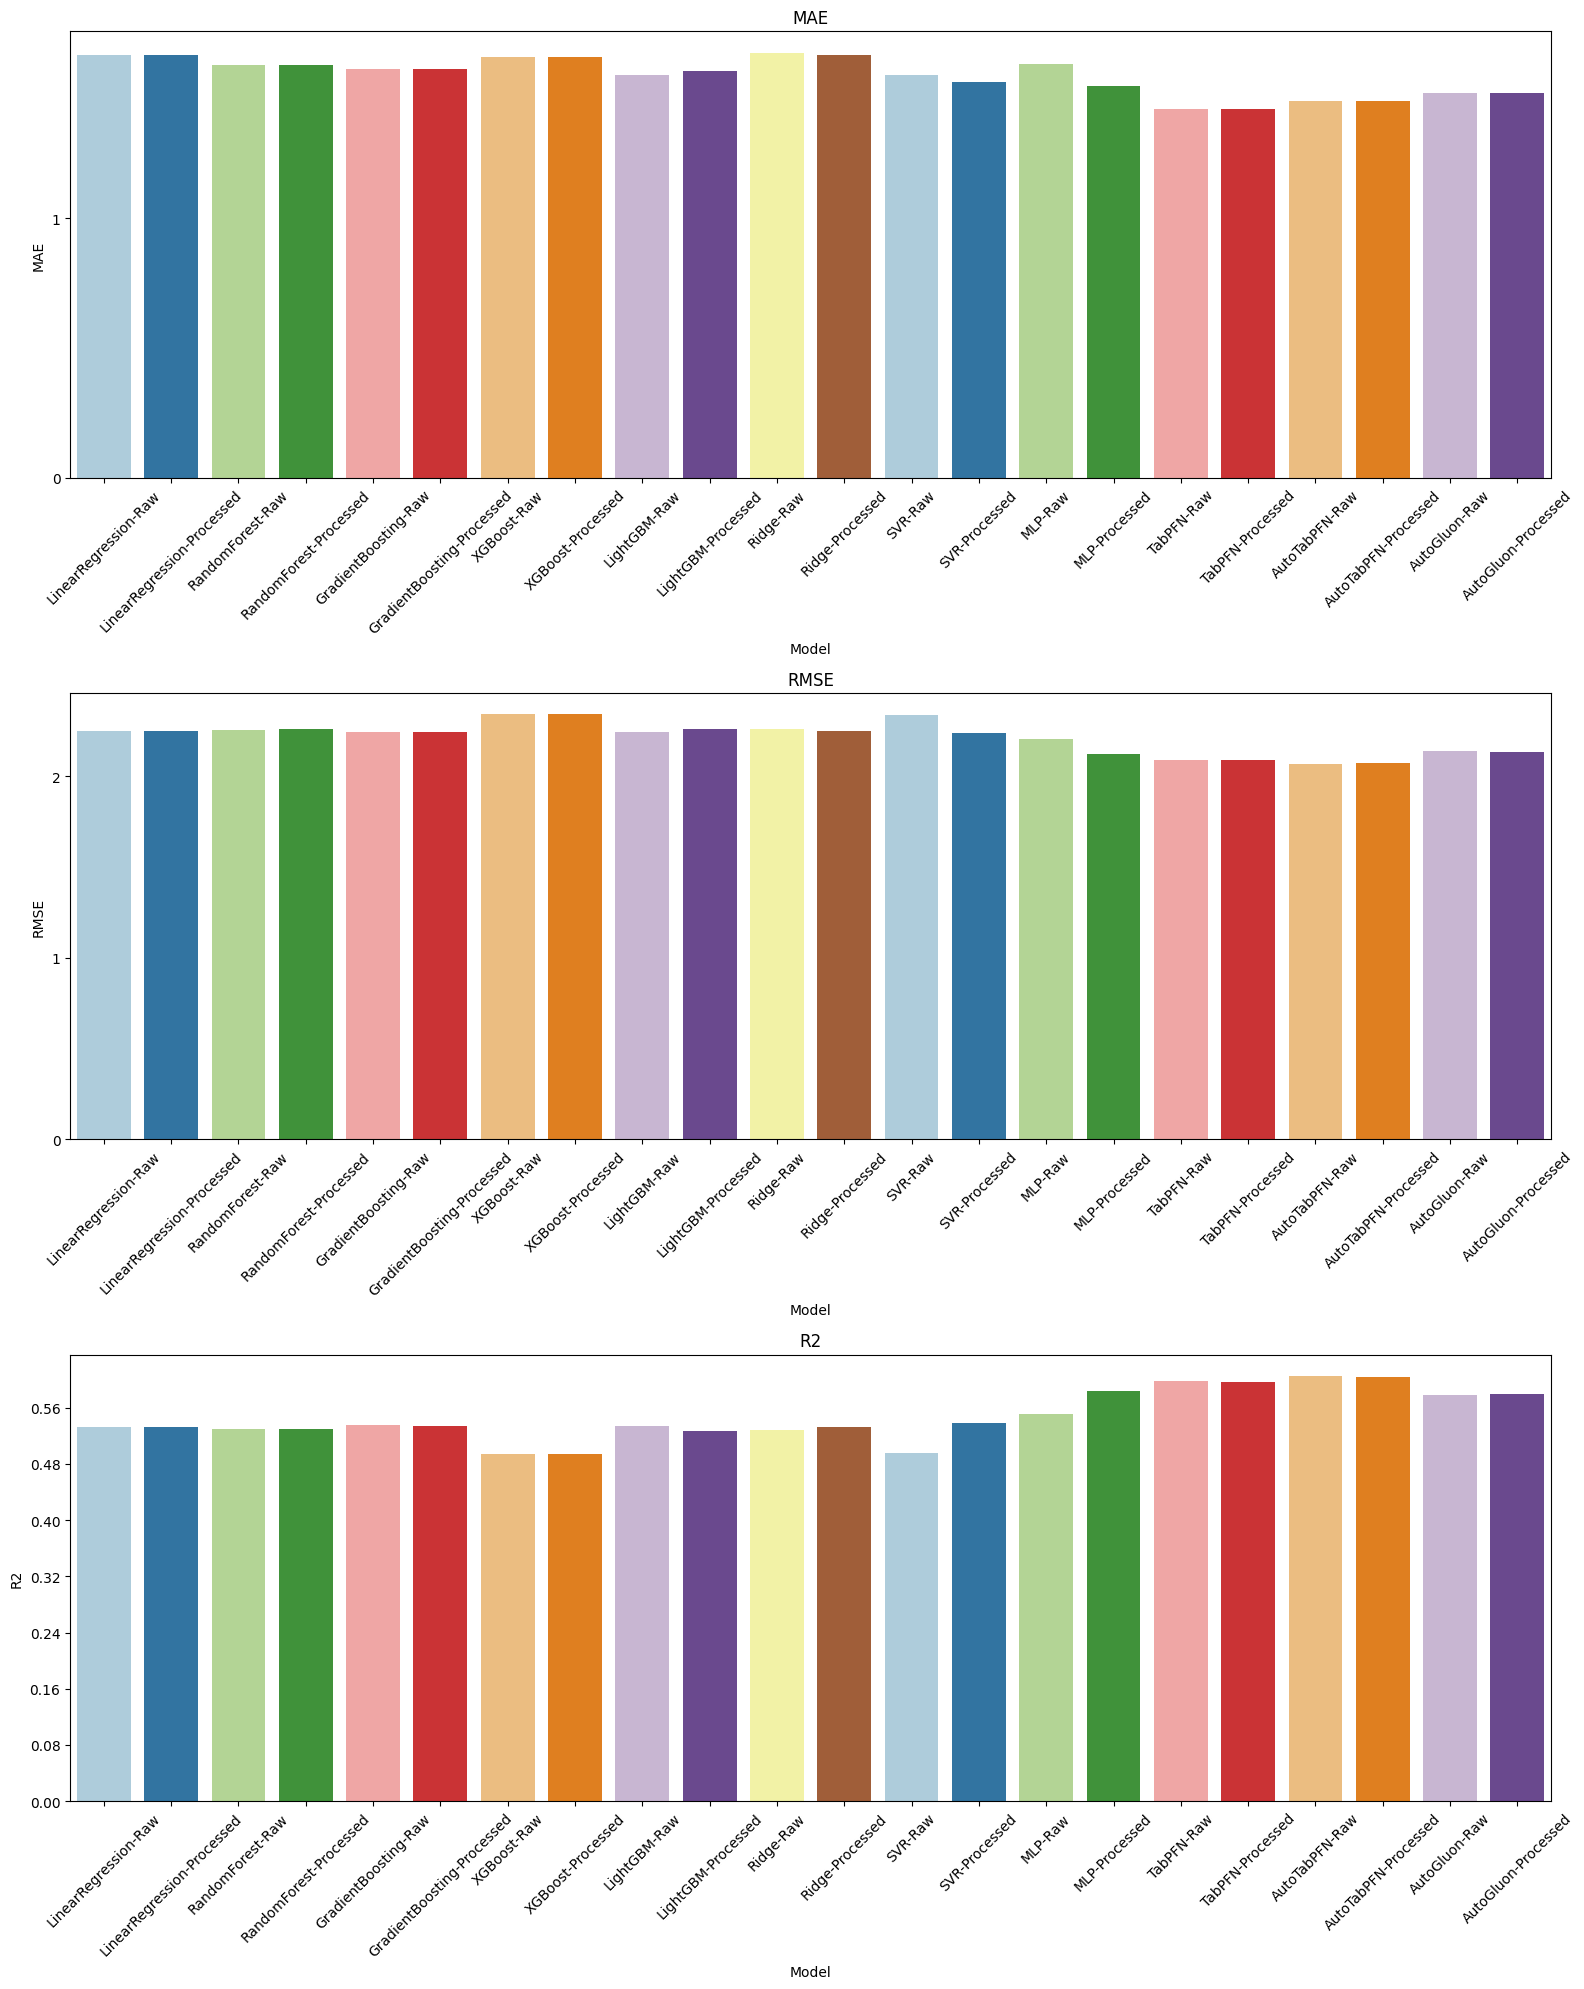

Wins per model (number of datasets where model was best):


Metric,MAE,RMSE,R2
Model,,,
TabPFN,2,0,0
AutoTabPFN,0,2,2


In [23]:
# Optional: Save metrics_df to CSV for external comparison
# metrics_df.to_csv("regression_model_metrics.csv", index=False)

# Extended: Display metrics and prepare normalized comparison
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Regression Performance Metrics:")

# Ensure DataFrame is correct
metrics_df = pd.DataFrame(results)
print("Columns in metrics_df:", metrics_df.columns.tolist())
display(metrics_df)

# Normalize metrics (lower is better for MAE/RMSE, higher is better for R2)
normalized_df = metrics_df.copy()
normalized_df["MAE"] = metrics_df["MAE"] / metrics_df["MAE"].mean()
normalized_df["RMSE"] = metrics_df["RMSE"] / metrics_df["RMSE"].mean()
normalized_df["R2"] = metrics_df["R2"] / metrics_df["R2"].max()
print("Normalized Performance Metrics:")
display(normalized_df)

# Visual summary bar plot (single column layout with larger dimensions)
fig, axes = plt.subplots(3, 1, figsize=(16, 20))  # Increased width and height
metrics = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics):
    sns.barplot(data=metrics_df, 
                x="Model", 
                y=metric, 
                ax=axes[i],
                palette="Paired")
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# --- Wins Calculation ---
from collections import defaultdict

metrics_df["Label"] = metrics_df["Model"].apply(lambda x: x.split("-")[-1])
metrics_df["BaseModel"] = metrics_df["Model"].apply(lambda x: "-".join(x.split("-")[:-1]))

wins = defaultdict(lambda: defaultdict(int))

for label in metrics_df["Label"].unique():
    subset = metrics_df[metrics_df["Label"] == label]

    for metric in ["MAE", "RMSE", "R2"]:
        if metric in ["MAE", "RMSE"]:
            best_idx = subset[metric].idxmin()
        else:
            best_idx = subset[metric].idxmax()

        best_model = metrics_df.loc[best_idx, "BaseModel"]
        wins[best_model][metric] += 1

wins_df = pd.DataFrame(wins).T.fillna(0).astype(int)
wins_df.columns.name = "Metric"
wins_df.index.name = "Model"

print("Wins per model (number of datasets where model was best):")
display(wins_df)

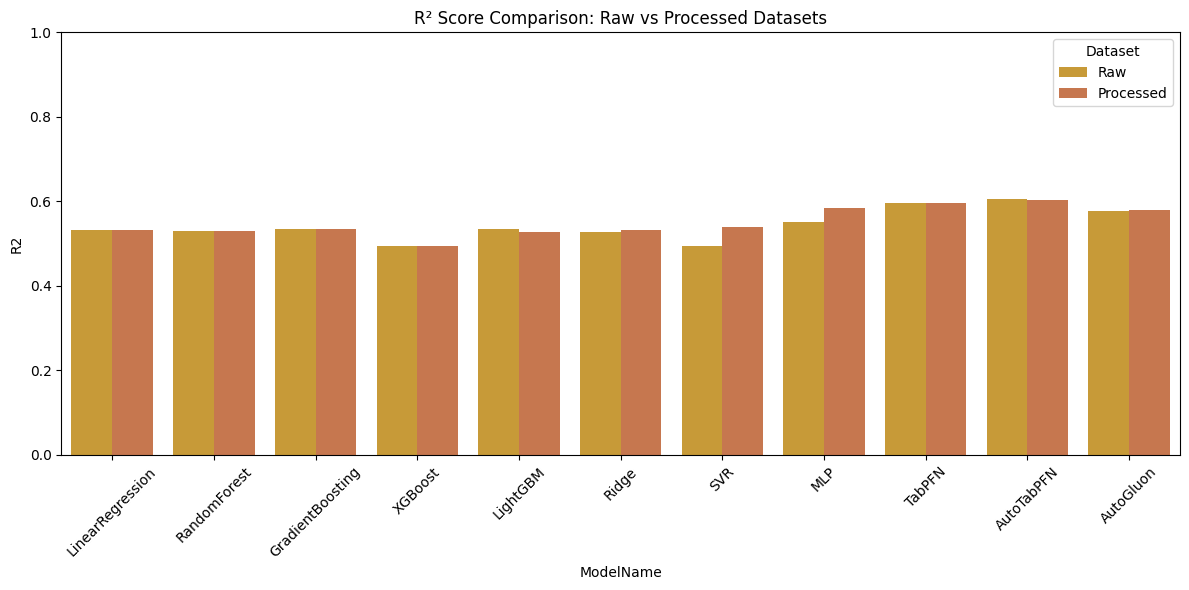

In [32]:
# Re-import necessary libraries after kernel reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = {
    "Raw": "#dfa320",
    "Processed": "#da713b"
}

# Split model type and dataset type
metrics_df[["ModelName", "Dataset"]] = metrics_df["Model"].str.split("-", expand=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="ModelName", y="R2", hue="Dataset", palette=custom_palette)
plt.title("R² Score Comparison: Raw vs Processed Datasets")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define binary classification thresholds
raw_thresh = raw_y_test.median()
proc_thresh = processed_y_test.median()

# Binarize targets
y_bin = {
    "Raw": (raw_y_test >= raw_thresh).astype(int),
    "Processed": (processed_y_test >= proc_thresh).astype(int)
}

# --- Define models and generate predictions ---
linear_model_raw = LinearRegression().fit(raw_X_train, raw_y_train)
linear_model_proc = LinearRegression().fit(processed_X_train, processed_y_train)
linreg_raw_preds = linear_model_raw.predict(raw_X_test)
linreg_proc_preds = linear_model_proc.predict(processed_X_test)

rf_model_raw = RandomForestRegressor(random_state=42).fit(raw_X_train, raw_y_train)
rf_model_proc = RandomForestRegressor(random_state=42).fit(processed_X_train, processed_y_train)
rf_raw_preds = rf_model_raw.predict(raw_X_test)
rf_proc_preds = rf_model_proc.predict(processed_X_test)

gb_model_raw = GradientBoostingRegressor(random_state=42).fit(raw_X_train, raw_y_train)
gb_model_proc = GradientBoostingRegressor(random_state=42).fit(processed_X_train, processed_y_train)
gb_raw_preds = gb_model_raw.predict(raw_X_test)
gb_proc_preds = gb_model_proc.predict(processed_X_test)

xgb_model_raw = xgb.XGBRegressor(random_state=42).fit(raw_X_train, raw_y_train)
xgb_model_proc = xgb.XGBRegressor(random_state=42).fit(processed_X_train, processed_y_train)
xgb_raw_preds = xgb_model_raw.predict(raw_X_test)
xgb_proc_preds = xgb_model_proc.predict(processed_X_test)

lgb_model_raw = lgb.LGBMRegressor(random_state=42).fit(raw_X_train, raw_y_train)
lgb_model_proc = lgb.LGBMRegressor(random_state=42).fit(processed_X_train, processed_y_train)
lgb_raw_preds = lgb_model_raw.predict(raw_X_test)
lgb_proc_preds = lgb_model_proc.predict(processed_X_test)

# TabPFN already predicted as raw_preds and proc_preds

In [29]:
# TabPFN
tabpfn_raw = TabPFNRegressor(device="cuda").fit(raw_X_train.values, raw_y_train.values)
raw_preds = tabpfn_raw.predict(raw_X_test.values)

tabpfn_proc = TabPFNRegressor(device="cuda").fit(processed_X_train.values, processed_y_train.values)
proc_preds = tabpfn_proc.predict(processed_X_test.values)

# AutoTabPFN
auto_model_raw = AutoTabPFNRegressor(device="cuda").fit(raw_X_train, raw_y_train)
auto_raw_preds = auto_model_raw.predict(raw_X_test)

auto_model_proc = AutoTabPFNRegressor(device="cuda").fit(processed_X_train, processed_y_train)
auto_proc_preds = auto_model_proc.predict(processed_X_test)

# AutoGluon
train_df_raw = raw_X_train.copy()
train_df_raw["target"] = raw_y_train
train_df_proc = processed_X_train.copy()
train_df_proc["target"] = processed_y_train

temp_dir_raw = tempfile.TemporaryDirectory()
temp_dir_proc = tempfile.TemporaryDirectory()

autogluon_model_raw = TabularPredictor(label="target", problem_type="regression", path=temp_dir_raw.name).fit(train_df_raw, verbosity=0)
autogluon_raw_preds = autogluon_model_raw.predict(raw_X_test)

autogluon_model_proc = TabularPredictor(label="target", problem_type="regression", path=temp_dir_proc.name).fit(train_df_proc, verbosity=0)
autogluon_proc_preds = autogluon_model_proc.predict(processed_X_test)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.2b20250729
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Nov 10 10:07:59 UTC 2024
CPU Count:          4
Memory Avail:       27.88 GB / 31.35 GB (88.9%)
Disk Space Avail:   18.14 GB / 19.52 GB (93.0%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'         : Strong accuracy with fast inf

In [30]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define binary classification thresholds
raw_thresh = raw_y_test.median()
proc_thresh = processed_y_test.median()

# Binarize targets
y_bin = {
    "Raw": (raw_y_test >= raw_thresh).astype(int),
    "Processed": (processed_y_test >= proc_thresh).astype(int)
}

# Predictions dictionary assumed (update these with your actual model predictions):
predictions = {
    "LinearRegression-Raw": linreg_raw_preds,
    "LinearRegression-Processed": linreg_proc_preds,
    "RandomForest-Raw": rf_raw_preds,
    "RandomForest-Processed": rf_proc_preds,
    "GradientBoosting-Raw": gb_raw_preds,
    "GradientBoosting-Processed": gb_proc_preds,
    "XGBoost-Raw": xgb_raw_preds,
    "XGBoost-Processed": xgb_proc_preds,
    "LightGBM-Raw": lgb_raw_preds,
    "LightGBM-Processed": lgb_proc_preds,
    "TabPFN-Raw": raw_preds,
    "TabPFN-Processed": proc_preds,
    "AutoTabPFN-Raw": auto_raw_preds,
    "AutoTabPFN-Processed": auto_proc_preds,
    "AutoGluon-Raw": autogluon_raw_preds,
    "AutoGluon-Processed": autogluon_proc_preds
}

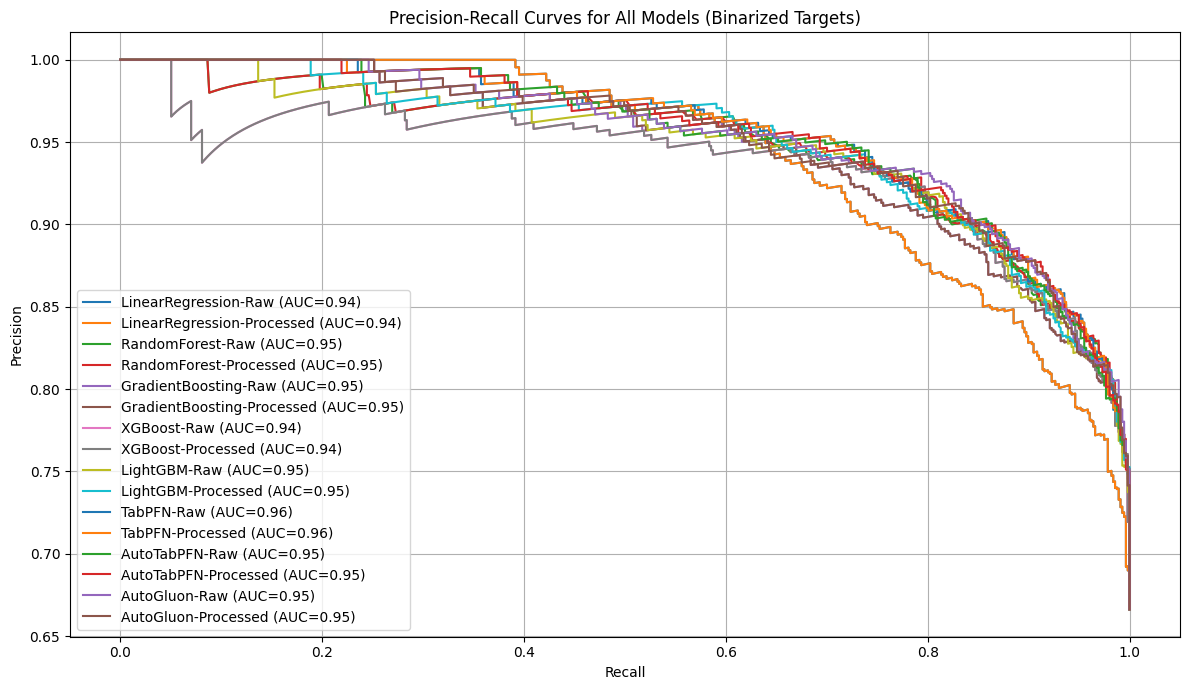

In [31]:
# Plot all PR curves
plt.figure(figsize=(12, 7))

for model_label, y_pred in predictions.items():
    dataset_type = "Raw" if "Raw" in model_label else "Processed"
    binary_y_true = y_bin[dataset_type]
    precision, recall, _ = precision_recall_curve(binary_y_true, y_pred)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{model_label} (AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Models (Binarized Targets)")
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()